# Language Model

The main goal of language model is to estimate the joint probability of the sequence :

$P(x_1, x_2, \ldots, x_T)$

For instance, the phrases “to recognize speech” and “to wreck a nice beach” sound very similar. This can cause ambiguity in speech recognition, which is easily resolved through a language model that rejects the second translation as outlandish.
In a document summarization algorithm it is worthwhile knowing that “dog bites man” is much more frequent than “man bites dog”, or that “I want to eat grandma” is a rather disturbing statement, whereas “I want to eat, grandma” is much more benign.

In [146]:
# Imports
import collections
import re
from dataclasses import dataclass
from pathlib import Path
from urllib.request import urlretrieve

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

Basic Probability Rule :

$$
P(x_1, x_2, \ldots, x_T) = \prod_{t=1}^T P(x_t  \mid  x_1, \ldots, x_{t-1}).
$$

$$
\begin{split}\begin{aligned}&P(\textrm{deep}, \textrm{learning}, \textrm{is}, \textrm{fun}) = P(\textrm{deep}) P(\textrm{learning}  \mid  \textrm{deep}) P(\textrm{is}  \mid  \textrm{deep}, \textrm{learning}) P(\textrm{fun}  \mid  \textrm{deep}, \textrm{learning}, \textrm{is}).\end{aligned}\end{split}
$$

A distribution over sequences satisfies the Markov property of first order if $P(x_{t+1} \mid x_t, \ldots, x_1) = P(x_{t+1} \mid x_t)$. Higher orders correspond to longer dependencies. This leads to a number of approximations that we could apply to model a sequence: 

$$
\begin{split}\begin{aligned}
P(x_1, x_2, x_3, x_4) &=  P(x_1) P(x_2) P(x_3) P(x_4),\\
P(x_1, x_2, x_3, x_4) &=  P(x_1) P(x_2  \mid  x_1) P(x_3  \mid  x_2) P(x_4  \mid  x_3),\\
P(x_1, x_2, x_3, x_4) &=  P(x_1) P(x_2  \mid  x_1) P(x_3  \mid  x_1, x_2) P(x_4  \mid  x_2, x_3).
\end{aligned}\end{split}
$$

Unigram, Bigram and Trigram

## Laplace Smoothing

$$
\begin{split}\begin{aligned}
    \hat{P}(x) & = \frac{n(x) + \epsilon_1/m}{n + \epsilon_1}, \\
    \hat{P}(x' \mid x) & = \frac{n(x, x') + \epsilon_2 \hat{P}(x')}{n(x) + \epsilon_2}, \\
    \hat{P}(x'' \mid x,x') & = \frac{n(x, x',x'') + \epsilon_3 \hat{P}(x'')}{n(x, x') + \epsilon_3}.
\end{aligned}\end{split}
$$

Adds a paramter $\alpha$ in general to the probability function in order to add non zero probability to the non observed n-gram sequences so that model is robust. It also slightly lowers the probability of observed (seen) sequences during the training. 

If $\alpha == 1$ then it is called laplace smoothing
else If $0 < \alpha < 1$ then it is called lindstone smoothing

General formula : 

$$
P(w_n \mid w_{n-1}, \ldots, w_1)
=
\frac{C(w_1,\ldots,w_n)+\alpha}
{C(w_1,\ldots,w_{n-1})+\alpha \cdot V}
$$

## Perplexity

$$
\exp\left(-\frac{1}{n} \sum_{t=1}^n \log P(x_t \mid x_{t-1}, \ldots, x_1)\right).
$$

Perplexity can be best understood as the reciprocal of the geometric mean of the number of real choices that we have when deciding which token to pick next. Let’s look at a number of cases:

- In the best case scenario, the model always perfectly estimates the probability of the target token as 1. In this case the perplexity of the model is 1.
- In the worst case scenario, the model always predicts the probability of the target token as 0. In this situation, the perplexity is positive infinity.
- At the baseline, the model predicts a uniform distribution over all the available tokens of the vocabulary. In this case, the perplexity equals the number of unique tokens of the vocabulary. In fact, if we were to store the sequence without any compression, this would be the best we could do for encoding it. Hence, this provides a nontrivial upper bound that any useful model must beat.

(source D2L.ai)

## Partitioning Sequences

This is the proposed sequence of partitioning to be done.

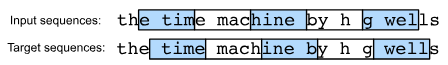

Input:
```
e time machine by h g wel
```
Target:
```
time machine by h g well
```

So our data would look something like this : 

```
Input subsequences:

[e tim] [e mac] [hine ] [by h ] [g wel]

Target subsequences:

[ time] [ mach] [ine b] [y h g] [ well]
```

Why this works is because in RNN we have hidden state carrying the info.

In [147]:
# Data Downloader and Processor
# ==============================

class TxtDataProcessor:
    def __init__(self, url: str, file_name: str):
        data_dir = Path("data")
        data_dir.mkdir(parents=True, exist_ok=True)
        file_path = data_dir / file_name

        if not file_path.exists():
            urlretrieve(url, file_path)
        self.file_path = file_path

    def _read_file(self):
        with open(self.file_path) as f:
            self.data = f.read()

    def _preprocess(self):
        self.preprocessed_data = re.sub('^A-Za-z]+', ' ', self.data).lower()

    def _tokenize(self) -> list[str]:
        return list(self.preprocessed_data)

class Vocab:
    def __init__(self, tokens: list[str] = [], min_freq: int = 0, reserved_tokens:list[str] = []):
        # flatten the token list (if needed)
        if tokens and isinstance(tokens[0], list):
            tokens = []
            for line in tokens:
                for token in line:
                    tokens.append(token)
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(
            counter.items(),
            key = lambda x: x[1], # sort by frequency
            reverse = True
        )
        self.index_to_token = sorted(set(
                ['<unk>'] + 
                reserved_tokens + 
                [
                    token for token, freq in self.token_freqs if freq >= min_freq
                ]
            ))
        self.token_to_index = {
            token: idx for idx, token in enumerate(self.index_to_token)
        }
    
    def __len__(self):
        return len(self.index_to_token)

    def __getitem__(self, tokens: list | tuple):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_index.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices: list[int]):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.index_to_token[int(index)] for index in indices]
        return self.index_to_token[indices]

    @property
    def unk(self):
        return self.token_to_index['<unk>']

In [148]:
# Vocabulary Build
# ===================

URL = "https://www.gutenberg.org/files/35/35-0.txt"
FILE_NAME = "time_machine.txt"

def build_vocab(url: str, file_name: str) -> tuple[list[str], Vocab]:
    data = TxtDataProcessor(url, file_name)
    data._read_file()
    data._preprocess()
    tokens = data._tokenize()
    vocab = Vocab(tokens)
    corpus = [vocab[token] for token in tokens]
    return corpus, vocab

corpus, vocab = build_vocab(URL, FILE_NAME)

In [149]:
# Build Dataset 
# ==================

@dataclass
class DataParams:
    train_percentage: int
    validation_percentage: int
    batch_size: int

class DataBuilder:
    def __init__(self, corpus: list[int], vocab: Vocab, num_steps: int, data_params: DataParams):
        self.vocab = vocab
        self.corpus = corpus
        self.data_params = data_params
        data = torch.tensor(
            [corpus[i: i+num_steps+1] for i in range(len(corpus) - num_steps)]
        )
        # X : all rows, cols except the last
        # Y : all rows, cols except the first
        X, Y = data[:,:-1], data[:,1:]
        # Divide the data set into chunks
        train_end = len(data) * data_params.train_percentage // 100
        validation_end = (train_end + len(data) * data_params.validation_percentage // 100)
        self.train_dataset = TensorDataset(X[:train_end], Y[:train_end])
        self.validation_dataset = TensorDataset(
            X[train_end:validation_end], Y[train_end:validation_end],
        )

def build_dataloader(data_builder: DataBuilder) -> tuple[DataLoader, DataLoader]:
    batch_size = data_builder.data_params.batch_size
    train_dataloader = DataLoader(
        data_builder.train_dataset,
        batch_size,
        shuffle=True
    )
    val_dataloader = DataLoader(
        data_builder.validation_dataset,
        batch_size,
        shuffle=False
    )
    return train_dataloader, val_dataloader

In [150]:
BATCH_SIZE = 2

data_builder = DataBuilder(
    corpus=corpus,
    vocab=vocab,
    num_steps=10,
    data_params=DataParams(70, 30, BATCH_SIZE)
)
train_dataloader, val_dataloader = build_dataloader(data_builder=data_builder)

for X, y in train_dataloader:
    # shape of X : (batch_size, sequence_length)
    # shape of y : (batch_size, sequence_length)
    print('X : ', X, '\ny: ', y)
    break

X :  tensor([[31, 37, 32,  1, 37, 25, 22,  1, 21, 18],
        [21,  1, 26, 31,  1, 18, 31, 32, 37, 25]]) 
y:  tensor([[37, 32,  1, 37, 25, 22,  1, 21, 18, 35],
        [ 1, 26, 31,  1, 18, 31, 32, 37, 25, 22]])


## Gradient Clipping 

Gradient clipping is a technique we use to counter the exploding gradients in deep neural networks. Because for each update we do during the back propogation our gradient might explode or vanish in certain values (we have initialisation techniques to counter this on off value but generally we will not be helping our training if there are several values which are very large or small as a vanishing or exploding update can ruin the previously trained steps)

We will do one clever thing here that we will clip our gradient to be in a certain range. We can call this a ball (yes ball is a mathematical language there is a difference between ball and a sphere.) and we can restrict the gradient updates to be well within that ball. This will solve our epxloding gradient problem while updates (Gradient clipping only helps in exploding gradients)

$$
\mathbf{g} \leftarrow \min\left(1, \frac{\theta}{\|\mathbf{g}\|}\right) \mathbf{g}.
$$

$\theta$ : Radius of the ball

$\mathbf{g}$ : Gradient

$\|\mathbf{g}\|$ : Norm of the gradient

Here we are basically projecting the values on to this ball (This line will make mathematicians my enemy but this is what we need to understand this).

In pytorch training loop we might do something like this : 

```py
loss.backward()

# After grad calc and before the weight updates
torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0
)

optimizer.step()
```

# Training a LM

In [151]:
# Imports

import sys
import math
import time

sys.path.insert(0, "..")

from src.lm import LM, LanguageModelParams
from src.rnn import RNNInputs

In [152]:
# constants

BATCH_SIZE = 256
EMBEDDING_SIZE = 200
SEQUENCE_LENGTH = 25
TRAIN, VALIDATION = 70, 30
VOCAB_SIZE = len(vocab)
HIDDEN_LAYER_SIZE = 256
HIDDEN_LAYER_SIZE_2 = 256
SIGMA = 0.1
LEARNING_RATE = 0.003
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [153]:
# Defining the model parameters and dat loaders

data_builder = DataBuilder(
    corpus=corpus,
    vocab=vocab,
    num_steps=SEQUENCE_LENGTH,
    data_params=DataParams(TRAIN, VALIDATION, BATCH_SIZE)
)
train_dataloader, val_dataloader = build_dataloader(data_builder=data_builder)

lm_params = LanguageModelParams(vocab_size=VOCAB_SIZE, embedding_size=EMBEDDING_SIZE)
rnn_params = [
    RNNInputs(EMBEDDING_SIZE, hidden_layer_size=HIDDEN_LAYER_SIZE, sigma=SIGMA),
    RNNInputs(HIDDEN_LAYER_SIZE, hidden_layer_size=HIDDEN_LAYER_SIZE_2, sigma=SIGMA),
]

model = LM(lm_params, rnn_params).to(DEVICE)
print(f"Training on {DEVICE}")

# We have the output layer as a linear layer and one might be 
# confused that why not softmax as we would like to play in terms of probability 
# of the next char. 
# 
# Here we use Cross entropy loss because it does the softmax (log softmax) inside it and 
# if ther correct preidcted token has a high prob --> low loss
# else if the correct predicted token has a low prob --> high loss
# This is what allows us to get the next token without using softmax in the output layer.
# Also this helps in the perplexity calculation as we can use the logits directly to calculate the perplexity.
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

Training on mps


In [154]:
# Training loop

def log_training_stats(epoch, epochs, loss, tokens, elapsed, print_every):
    if epoch != 1 and epoch % print_every != 0 and epoch != epochs:
        return

    filled = round(24 * epoch / epochs)
    bar = "█" * filled + "░" * (24 - filled)
    print(
        f"[{bar}] {epoch:>{len(str(epochs))}}/{epochs} • "
        f"loss {loss:.4f} • ppl {math.exp(loss):.2f} • "
        f"{tokens / elapsed:,.0f} tok/s • {elapsed:.1f}s"
    )

def train(model, dataloader, optimizer, loss_fn, epochs, device, print_every=10):
    print(f"Training on {device} • {len(dataloader):,} batches per epoch\n")
    for epoch in range(1, epochs + 1):
        started = time.perf_counter()
        model.train()
        total_loss = 0.0
        total_tokens = 0

        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits, _ = model(X, states=None)
            loss = loss_fn(
                # (-1, vocab_size)
                logits.reshape(-1, logits.size(-1)),
                y.reshape(-1),
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item() * y.numel()
            total_tokens += y.numel()

        log_training_stats(
            epoch, epochs, total_loss / total_tokens, total_tokens,
            time.perf_counter() - started, print_every,
        )

EPOCHS = 20
train(model, train_dataloader, optimizer, loss_fn, EPOCHS, DEVICE, print_every=2)

Training on mps • 492 batches per epoch

[█░░░░░░░░░░░░░░░░░░░░░░░]  1/20 • loss 1.5377 • ppl 4.65 • 598,202 tok/s • 5.3s
[██░░░░░░░░░░░░░░░░░░░░░░]  2/20 • loss 1.2179 • ppl 3.38 • 648,609 tok/s • 4.9s
[█████░░░░░░░░░░░░░░░░░░░]  4/20 • loss 1.0614 • ppl 2.89 • 661,006 tok/s • 4.8s
[███████░░░░░░░░░░░░░░░░░]  6/20 • loss 0.9976 • ppl 2.71 • 660,194 tok/s • 4.8s
[██████████░░░░░░░░░░░░░░]  8/20 • loss 0.9658 • ppl 2.63 • 640,891 tok/s • 4.9s
[████████████░░░░░░░░░░░░] 10/20 • loss 0.9435 • ppl 2.57 • 660,010 tok/s • 4.8s
[██████████████░░░░░░░░░░] 12/20 • loss 0.9304 • ppl 2.54 • 665,754 tok/s • 4.7s
[█████████████████░░░░░░░] 14/20 • loss 0.9200 • ppl 2.51 • 665,749 tok/s • 4.7s
[███████████████████░░░░░] 16/20 • loss 0.9147 • ppl 2.50 • 673,778 tok/s • 4.7s
[██████████████████████░░] 18/20 • loss 0.9111 • ppl 2.49 • 676,397 tok/s • 4.7s
[████████████████████████] 20/20 • loss 0.9078 • ppl 2.48 • 674,686 tok/s • 4.7s


In [155]:
# Validation loop

@torch.no_grad()
def validate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        logits, _ = model(X, states=None)
        targets = y
        loss = loss_fn(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        total_loss += loss.item() * targets.numel()
        total_tokens += targets.numel()

    average_loss = total_loss / total_tokens
    perplexity = math.exp(average_loss)
    print(f"Validation Loss: {average_loss:.4f} | Perplexity: {perplexity:.2f}")
    return average_loss, perplexity

validation_loss, validation_perplexity = validate(model, val_dataloader, loss_fn, DEVICE)

Validation Loss: 2.0097 | Perplexity: 7.46


In [158]:
# Generate a character stream while carrying recurrent states forward

@torch.no_grad()
def generate_char_stream(
    model, vocab, text: str, stream_length: int,
    strategy: str = "argmax", temperature: float = 1.0, device=DEVICE,
):
    if not text:
        raise ValueError("text must not be empty")
    if stream_length < 0:
        raise ValueError("stream_length must not be negative")
    if strategy not in {"argmax", "temperature"}:
        raise ValueError("strategy must be 'argmax' or 'temperature'")
    if strategy == "temperature" and temperature <= 0:
        raise ValueError("temperature must be greater than zero")

    model.eval()
    tokens = torch.tensor([vocab[list(text.lower())]], device=device)
    logits, states = model(tokens, states=None)
    generated = text

    for _ in range(stream_length):
        next_logits = logits[0, -1]
        if strategy == "argmax":
            next_token = next_logits.argmax()
        else:
            probabilities = torch.softmax(next_logits / temperature, dim=-1)
            next_token = torch.multinomial(probabilities, 1)

        generated += vocab.to_tokens(next_token.item())
        logits, states = model(next_token.view(1, 1), states=states)

    return generated, states

# Greedy: generate_char_stream(model, vocab, "Always keep in mind tha", 90)
# Sampling: generate_char_stream(
#     model, vocab, "Always keep in mind tha", 90,
#     strategy="temperature", temperature=0.8,
# )

PROMPT = "he called me and sa"
GEN_TOKENS = 50
TEMPERATURE = 0.8

generated_text, final_states = generate_char_stream(
    model,
    vocab,
    PROMPT,
    GEN_TOKENS,
    strategy="temperature",
    temperature=TEMPERATURE,
)
print("Prompt length: ", len(PROMPT))

print("\n")

print(f"Prompt: {PROMPT}\n=================================\nGenerated Text (Temperature): {generated_text}")

print("\n")

generated_text, final_states = generate_char_stream(model, vocab, PROMPT, GEN_TOKENS)
print(f"Prompt: {PROMPT}\n=================================\nGenerated Text (Greedy): {generated_text}")

Prompt length:  19


Prompt: he called me and sa
Generated Text (Temperature): he called me and savage animal in the
same bar, i and tolects had imi


Prompt: he called me and sa
Generated Text (Greedy): he called me and saw it
first place, i saw the little people were sli
